---
title: "Fine-tuning Whisper Without Catastrophic Forgetting"
description: |
  Week 5 of the residency. How sound becomes something a transformer can read, and what a handful of gradient steps on one clip actually does.
author: Rosh Beed
date: '2026-07-06'
image: figures/slide-06.png
categories:
  - audio
  - speech
  - fine-tuning
  - week-5
jupyter: python3
---


Text was week 1, images were week 3, and the argument each time was that the
transformer doesn't care what the input was, as long as it arrives as a sequence
of vectors. Audio is the third test of that claim.

Two tasks.

![](figures/slide-02.png){fig-alt="Task one: classify. An audio waveform, then the same clip as a spectrogram, with two routes labelled \"classify using a CNN\" and \"classify using a Transformer\", annotated \"clearly images :)\"."}

Note the annotation on that slide. Once audio is a spectrogram it's a
two-dimensional array of intensities. That's a picture, and the patch projection
from week 3 works on it unchanged.

![](figures/slide-03.png){fig-alt="Task two: fine-tune. Two audio clips and their spectrograms feeding a Base Whisper and a Tuned Whisper, both producing \"Hello, my name is Bes.\""}

The second task is the one this post follows, and there's the running example
again. *Hello, my name is Bes* was the sentence CBOW completed in week 1. Here a
speech model has to hear it.

## What Sound Is

![](figures/slide-11.png){fig-alt="Two waveforms, street music and a jackhammer, each beside the sine waves it decomposes into: 40, 220 and 300 Hz for the music, 700, 330 and 1500 Hz for the jackhammer."}

A waveform is amplitude over time, sampled 16,000 times a second, and almost none
of the structure a listener cares about is visible in it directly. Two different
sounds are two different bundles of vibrations at different frequencies.

![](figures/slide-12.png){fig-alt="A street-music waveform beside its frequency spectrum, magnitude against frequency."}

The Fourier transform unbundles it. Run it over short overlapping windows rather
than the whole clip and you get frequency on one axis, time on the other, intensity
as the value. That is the spectrogram, and it is why the previous slide could call
audio "clearly images".

Whisper adds two refinements.

* The frequency axis is squashed onto the **mel scale**. It spaces bands the way
  hearing does: fine detail low down, coarser high up. 80 bands replace 201 raw
  frequency bins.
* The values go through a **logarithm**, because loudness is perceived
  multiplicatively.

Below is that whole front end, built from scratch on the actual clip from the
project, so you can see the waveform go in and the picture come out.

In [1]:
#| warning: false

# Setup, inlined rather than imported so this notebook runs on its own.
# Keep it folded; nothing below it depends on anything outside this file.

import torch.nn as nn
import visualtorch
import matplotlib.pyplot as plt

# --- chart styling -------------------------------------------------------
# Categorical slots of a CVD-validated palette: blue, orange, aqua, purple.
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#8a63d2"]
MUTED, GRID, AXIS = "#5b6570", "#e6e6e3", "#d5d5d1"


def style_axes(ax, xlabel=None, ylabel=None, grid="y"):
    """Strip an axes back to the ink that carries information."""
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    return ax


def figure(width=7.0, height=4.2, **kw):
    fig, ax = plt.subplots(figsize=(width, height), **kw)
    return fig, ax

# --- visualtorch, configured ---------------------------------------------
# Dropout is hidden: nn.TransformerEncoderLayer exposes its internal Dropout as a
# traceable leaf, every model here builds it with dropout=0.0, and drawing a no-op
# layer says it is part of the architecture when it is not. Uncoloured it also took
# visualtorch's default orange, near enough to MultiheadAttention's to be confusing.
COLOUR_MAP = {
    nn.Linear: {"fill": COLOURS[0]},
    nn.MultiheadAttention: {"fill": COLOURS[1]},
    nn.Embedding: {"fill": COLOURS[3]},
    nn.LayerNorm: {"fill": "#aeb6bf"},
    nn.GELU: {"fill": COLOURS[2]},
    nn.ReLU: {"fill": COLOURS[2]},
    nn.Flatten: {"fill": "#aeb6bf"},
    nn.Dropout: {"fill": "#e6e6e3"},
}
_COMMON = dict(color_map=COLOUR_MAP, connector_fill="#c3c9d0", background_fill="white",
               font_color=MUTED, legend=True, show_dimension=True,
               type_ignore=[nn.Dropout])


def diagram(model, input_shape, style="graph", **overrides):
    """Render `model` as a PIL image in this site's colours.

    `graph` draws real neurons and suits a short stack; `flow` draws volumetric
    blocks whose size tracks the layer's and stays readable on a deep one. `flow`
    reports a 3-D activation as (1, 1, width), losing the sequence length, so its
    shape labels are off. `level_gap=1` keeps a residual connection drawn close to
    the blocks it skips.
    """
    if style == "graph":
        settings = dict(node_size=24, layer_spacing=110, node_spacing=8,
                        ellipsize_after=5, **_COMMON)
    else:
        settings = dict(spacing=26, scale_xy=2.4, max_xy=280, one_dim_orientation="y",
                        level_gap=1, **_COMMON)
        settings["show_dimension"] = False
    settings.update(overrides)
    return visualtorch.render(model, input_shape=input_shape, style=style, **settings)

# --- the log-mel picture -------------------------------------------------
DYNAMIC_RANGE = 8.0      # Whisper clamps the quiet end this far below the loudest


def log_mel(x, bank, n_fft, hop):
    """A waveform in, a log-mel picture out, time down the rows."""
    power = np.abs(stft(x, n_fft, hop)) ** 2
    picture = np.log10(np.maximum(bank @ power, 1e-10))
    return np.maximum(picture, picture.max() - DYNAMIC_RANGE).T.astype(np.float32)


import numpy as np
from huggingface_hub import hf_hub_download

REVISION = "f705fed08827ff6c36e3b5329495c943a5e544e8"
clip = np.load(hf_hub_download("roshbeed/ai-residency-blog-data", "audio/clip-16k.npz",
                               repo_type="dataset", revision=REVISION))
waveform, rate = clip["waveform"], int(clip["sample_rate"])

N_FFT, HOP, N_MELS = 400, 160, 80

def stft(x, n_fft, hop):
    """Fourier transform of each short overlapping window."""
    window = np.hanning(n_fft + 1)[:-1]
    frames = 1 + (len(x) - n_fft) // hop
    return np.stack([np.fft.rfft(x[i * hop:i * hop + n_fft] * window)
                     for i in range(frames)], axis=1)

def mel_filterbank(rate, n_fft, n_mels):
    """Triangular filters, evenly spaced on the mel scale rather than in hertz."""
    to_mel = lambda f: 2595 * np.log10(1 + f / 700)
    to_hz = lambda m: 700 * (10 ** (m / 2595) - 1)
    edges = to_hz(np.linspace(to_mel(0), to_mel(rate / 2), n_mels + 2))

    # The actual frequency of each FFT bin. Rounding the triangle corners to whole
    # bins instead is the tempting shortcut, and down here the mel bands are
    # narrower than one bin is wide, so several of them round onto the same corner
    # and come out empty.
    freqs = np.linspace(0, rate / 2, n_fft // 2 + 1)

    bank = np.zeros((n_mels, len(freqs)))
    for m in range(n_mels):
        left, centre, right = edges[m], edges[m + 1], edges[m + 2]
        rising = (freqs - left) / (centre - left)
        falling = (right - freqs) / (right - centre)
        bank[m] = np.maximum(0.0, np.minimum(rising, falling))
        bank[m] *= 2.0 / (right - left)     # equal area, so a wide band cannot shout
    return bank

bank = mel_filterbank(rate, N_FFT, N_MELS)
print(f"{N_MELS} filters over {bank.shape[1]} frequency bins, "
      f"{(bank.sum(1) == 0).sum()} of them empty")
spans = np.count_nonzero(bank, axis=1)
print(f"the narrowest covers {spans.min()} frequency bin, the widest {spans.max()}")


80 filters over 201 frequency bins, 0 of them empty
the narrowest covers 1 frequency bin, the widest 14


/Users/rosh/mlx/roshbeed.github.io/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Every band carries signal, and the low ones are narrow where the high ones are
wide. That spacing is what the mel scale is for. Now push the clip through them.

In [2]:
power = np.abs(stft(waveform, N_FFT, HOP)) ** 2
picture = np.log10(np.maximum(bank @ power, 1e-10))

# Whisper clamps the quiet end to 8 log units below the loudest point. Without it
# the floor above sets the bottom of the colour scale at -10 and every real value
# is squashed into the top of the range.
picture = np.maximum(picture, picture.max() - 8.0)

print(f"{len(waveform):,} samples at {rate} Hz = {len(waveform) / rate:.2f} seconds")
print(f"becomes an {picture.shape[0]} by {picture.shape[1]} picture, "
      f"values from {picture.min():.1f} to {picture.max():.1f}")

16,982 samples at 16000 Hz = 1.06 seconds
becomes an 80 by 104 picture, values from -6.9 to 1.1


A second of sound, 17,000 numbers long, comes out as an 80 by 104 grid. That grid
is what the model reads.

Drawn, the waveform and the picture it becomes:

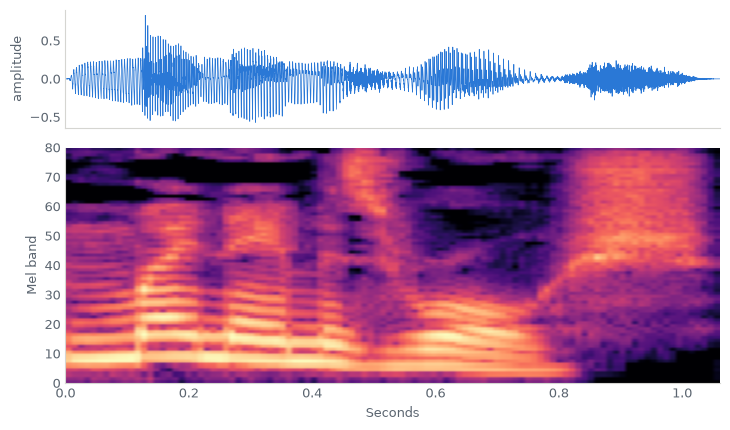

In [3]:
#| label: fig-mel
#| fig-cap: One second of speech, before and after. The model never sees the waveform on top.
#| fig-alt: A waveform above, and below it a spectrogram. The lower mel bands are brightest, with a stack of evenly spaced horizontal lines running through the middle of the picture that bend and break as the speech changes.

import matplotlib.pyplot as plt

fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.4, 4.4),
                                  gridspec_kw={"height_ratios": [1, 2]})
top.plot(np.arange(len(waveform)) / rate, waveform, color=COLOURS[0], linewidth=0.5)
top.set_xlim(0, len(waveform) / rate)
style_axes(top, ylabel="amplitude", grid=None)
top.set_xticks([])
bottom.imshow(picture, aspect="auto", origin="lower", cmap="magma",
              extent=(0, len(waveform) / rate, 0, N_MELS))
style_axes(bottom, "Seconds", "Mel band", grid=None)
fig.tight_layout()

## Whisper

![](figures/slide-06.png){fig-alt="Whisper's architecture: a log-mel spectrogram through two convolutions and sinusoidal positional encoding into transformer encoder blocks, with transformer decoder blocks cross-attending to them and producing tokens."}

An encoder over the spectrogram, a decoder cross-attending to it. Structurally this
is [week 3's multi-digit reader](../2026-06-25-encoder-decoder-transformers/) with a
spectrogram where the image was, which is the claim the week set out to test.

The two convolutions at the front are doing something worth noticing: the second
has stride 2, halving the sequence from 3000 positions to 1500. Attention cost
grows with the square of sequence length, so that one layer is a four-fold saving
before any attention runs.

And a Whisper transcript does not start with words. It starts with a structured
token prefix, which is how one model handles transcription, translation and
language identification without being three models. For the running example that prefix is `<|startoftranscript|><|en|><|transcribe|><|notimestamps|>`,
and the words follow it.

## Fine-tuning on One Example

![](figures/slide-14.png){fig-alt="Tune result: the baseline transcription \"Hello, my name is Bess.\" against the target \"Hello, my name is Bes.\", with target and output token ids and the loss falling from 0.5395 to 0.1766."}

The base model mishears the name. Bess, with two esses.

The workshop's demonstration is to fine-tune on that one clip and watch it correct,
which makes the mechanism visible in a way a held-out score never does. It also
makes something else visible, which is what the rest of this post measures.

So the rest of this post runs Whisper. Not a model of its shape at a size that
trains in seconds — the released `whisper-tiny` weights, on read speech, measured
before and after.

In [4]:
import re

import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

SPEECH = "d1d9f7d1de9f83341127136398d76cce20275dd5"
data = np.load(hf_hub_download("roshbeed/ai-residency-blog-data",
                               "speech/librispeech-dummy.npz",
                               repo_type="dataset", revision=SPEECH),
               allow_pickle=True)
offsets, transcripts = data["offsets"], list(data["texts"])
samples = data["audio"]          # read out once; the .npz is lazily decompressed
clips = [samples[offsets[i]:offsets[i + 1]].astype(np.float32) / 32768.0
         for i in range(len(transcripts))]

MODEL = "openai/whisper-tiny"
processor = WhisperProcessor.from_pretrained(MODEL)
model = WhisperForConditionalGeneration.from_pretrained(MODEL).to(DEVICE)

print(f"{len(clips)} clips, {sum(map(len, clips)) / 16000:.0f} seconds of speech")
print(f"{MODEL}: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M parameters")


73 clips, 481 seconds of speech
openai/whisper-tiny: 37.8M parameters


These are the released `whisper-tiny` weights, and the speech is eight minutes of
LibriSpeech read aloud by people the model has never heard.

First, how good is it before anything is done to it. Word error rate counts
substitutions, deletions and insertions against the reference, divided by the
number of words in it, so 0 is perfect and 1 is as many mistakes as words.


In [5]:
def normalise(text):
    """LibriSpeech is uppercase and unpunctuated; Whisper is neither."""
    return re.sub(r"[^A-Z' ]", "", text.upper()).split()


def edits(reference, hypothesis):
    """Levenshtein distance over words, which is the arithmetic inside WER."""
    previous = list(range(len(hypothesis) + 1))
    for i, want in enumerate(reference, 1):
        current = [i]
        for j, got in enumerate(hypothesis, 1):
            current.append(min(previous[j] + 1, current[j - 1] + 1,
                               previous[j - 1] + (want != got)))
        previous = current
    return previous[-1]


@torch.no_grad()
def transcribe(indices, batch=16):
    out = []
    for start in range(0, len(indices), batch):
        chunk = [clips[i] for i in indices[start:start + batch]]
        features = processor(chunk, sampling_rate=16000,
                             return_tensors="pt").input_features
        tokens = model.generate(features.to(DEVICE), language="en", task="transcribe")
        out += processor.batch_decode(tokens, skip_special_tokens=True)
    return out


def word_error_rate(indices):
    errors = words = 0
    for i, hypothesis in zip(indices, transcribe(indices)):
        reference = normalise(transcripts[i])
        errors += edits(reference, normalise(hypothesis))
        words += len(reference)
    return errors / words


everything = list(range(len(clips)))
print(f"word error rate over all {len(clips)} clips: {word_error_rate(everything):.3f}")


[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] The attention mask is not set with a batched input, and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


word error rate over all 73 clips: 0.129


That is the number to keep an eye on. Everything below is measured against it.

Now find something it gets wrong. Not a contrived input — just the clip in the
first dozen it handles worst.


In [6]:
scores = [(word_error_rate([i]), i) for i in range(12)]
worst, chosen = max(scores)

print(f"clip {chosen} is the worst of the first twelve, at {worst:.3f}")
print(f"  reference:  {transcripts[chosen]}")
print(f"  whisper:    {transcribe([chosen])[0].strip()}")


clip 4 is the worst of the first twelve, at 0.206
  reference:  LINNELL'S PICTURES ARE A SORT OF UP GUARDS AND AT EM PAINTINGS AND MASON'S EXQUISITE IDYLLS ARE AS NATIONAL AS A JINGO POEM MISTER BIRKET FOSTER'S LANDSCAPES SMILE AT ONE MUCH IN THE SAME WAY THAT MISTER CARKER USED TO FLASH HIS TEETH AND MISTER JOHN COLLIER GIVES HIS SITTER A CHEERFUL SLAP ON THE BACK BEFORE HE SAYS LIKE A SHAMPOOER IN A TURKISH BATH NEXT MAN


  whisper:    Lennils, pictures are a sort of upguards and atom paintings, and Mason's exquisite Idols are as national as a jingo poem. Mr. Birkut Foster's landscapes smile at one much in the same way that Mr. Karker used to flash his teeth. And Mr. John Colier gives his sitter a cheerful slap on the back before he says, like a shampoo or a turkish bath, next man,


A model that works, and one specific thing it gets wrong. Fine-tune on that single
clip and watch two numbers: the loss on the clip, and the word error rate on clips
nobody asked it to change.

Those watched clips are held out of every run below, rehearsal included, so the
retention number is never measured on something the model was just trained on.

One Whisper detail decides whether this works at all. The tokenizer puts
`<|startoftranscript|>` at the front of a transcript, and the model prepends
`decoder_start_token_id` itself when it shifts the labels right. That token is
start-of-transcript. Pass the tokenizer's output through unchanged and the decoder
trains one position out of step. Nothing raises, the loss still falls, and the
model learns a different task from the one you meant.


In [7]:
import copy

SOT = processor.tokenizer.convert_tokens_to_ids("<|startoftranscript|>")
STEPS = 13


def labels_for(text):
    """Drop the tokenizer's start token; the model adds its own."""
    ids = processor.tokenizer(text, return_tensors="pt").input_ids[0]
    assert ids[0].item() == SOT, "tokenizer no longer starts with SOT"
    return ids[1:]


def batch_for(indices):
    """Features and right-padded labels; -100 keeps padding out of the loss."""
    features = processor([clips[i] for i in indices], sampling_rate=16000,
                         return_tensors="pt").input_features.to(DEVICE)
    sequences = [labels_for(transcripts[i]) for i in indices]
    labels = torch.full((len(indices), max(len(s) for s in sequences)), -100)
    for row, sequence in enumerate(sequences):
        labels[row, :len(sequence)] = sequence
    return features, labels.to(DEVICE)


others = [i for i in everything if i != chosen]
pool, watched = others[:8], others[8:]
baseline = copy.deepcopy(model.state_dict())
target = batch_for([chosen])

print(f"fine-tune on clip {chosen}, rehearse from {len(pool)}, "
      f"watch {len(watched)} the model never sees")


def fine_tune(rehearse, seed=0):
    """Reset to the released weights, then take STEPS on the one clip.

    `rehearse` is how many already-correct clips ride along in each batch.
    """
    model.load_state_dict(baseline)
    optimiser = torch.optim.AdamW(model.parameters(), lr=1e-4)
    generator = torch.Generator().manual_seed(seed)
    losses, clip_wer, watched_wer = [], [], []

    for step in range(STEPS):
        if step:
            picked = [chosen]
            if rehearse:
                order = torch.randperm(len(pool), generator=generator)
                picked += [pool[j] for j in order[:rehearse].tolist()]
            features, labels = batch_for(picked)
            loss = model(input_features=features, labels=labels).loss
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

        # The clip's own loss either way, so the two runs plot against each other.
        with torch.no_grad():
            losses.append(model(input_features=target[0], labels=target[1]).loss.item())
        clip_wer.append(word_error_rate([chosen]))
        watched_wer.append(word_error_rate(watched))
        print(f"{step:>5} {losses[-1]:>9.4f} {clip_wer[-1]:>11.3f} "
              f"{watched_wer[-1]:>14.3f}")

    return losses, clip_wer, watched_wer


print(f"\n{'step':>5} {'loss':>9} {'this clip':>11} {'the watched':>14}")
naive_loss, naive_clip, naive_watched = fine_tune(rehearse=0)


fine-tune on clip 4, rehearse from 8, watch 64 the model never sees

 step      loss   this clip    the watched


    0    1.7482       0.206          0.131


    1    0.8063       0.206          0.129


    2    0.4003       0.147          0.130


    3    0.2275       0.000          0.136


...

    8    0.1257       0.044          0.286


    9    0.1213       0.044          0.690


   10    0.1168       0.044          0.705


   11    0.1121       0.044          0.955


   12    0.1075       0.044          0.925


Three steps and the clip is transcribed exactly right. Nothing after that improves
it. The clip sits at 0.044 from step six onward while the loss crawls from 0.149 to
0.108, which is the model memorising a transcript it already gets right.

The right-hand column is what those steps cost. Word error rate on the sixty-four
watched clips goes 0.136, 0.194, 0.690, 0.925. The model ends barely able to
transcribe speech it handled fine twelve steps earlier, and the loss being
optimised fell the whole way.

Both numbers on one chart, the clip's loss against the watched set's error rate:


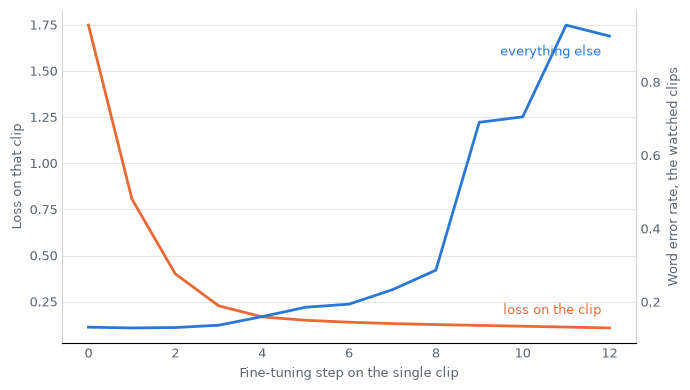

In [8]:
#| label: fig-forget
#| fig-cap: The fix lands within a few steps. Everything after that is the model memorising one clip at the expense of the clips it was never asked to change.
#| fig-alt: Two lines over twelve fine-tuning steps. The loss on the single clip falls steeply towards zero in the first few steps; the word error rate on the other clips holds briefly and then climbs steadily.

import matplotlib.pyplot as plt

fig, ax = figure(height=4.0)
ax.plot(range(STEPS), naive_loss, color=COLOURS[1], linewidth=2)
style_axes(ax, "Fine-tuning step on the single clip", "Loss on that clip")
ax.annotate("loss on the clip", xy=(STEPS - 1, naive_loss[-1]), xytext=(-6, 10),
            textcoords="offset points", ha="right", fontsize=9, color=COLOURS[1])

right = ax.twinx()
right.plot(range(STEPS), naive_watched, color=COLOURS[0], linewidth=2)
right.set_ylabel("Word error rate, the watched clips", color=MUTED, fontsize=9)
right.tick_params(colors=MUTED, labelsize=9, length=0)
for side in ("top", "left"):
    right.spines[side].set_visible(False)
right.spines["right"].set_color(AXIS)
right.annotate("everything else", xy=(STEPS - 1, naive_watched[-1]), xytext=(-6, -14),
               textcoords="offset points", ha="right", fontsize=9, color=COLOURS[0])
fig.tight_layout()


The fix is cheap. A few gradient steps and the clip is transcribed correctly.

The loss then falls to nearly zero. That looks like good news. It is not.

With one training example, a loss near zero means the model has memorised that
clip. It is what you asked for. It is also what goes wrong quietly when the same
procedure is scaled up.

The cost lands where nobody is looking. Word error rate on the watched clips goes
from 0.131 to 0.925, from a working transcriber to one that gets most words wrong,
while the only number the loop prints is going down.


## Keeping the Rest of It

Nothing in that loop constrains the other clips. The only gradient comes from one
example, so that example is the only term in the objective and the rest of the
function is unconstrained.

Rehearsal puts the old task back in the batch. Alongside the clip being fixed, each
step carries a few clips the model already handles, drawn from a pool held aside
for it. Their loss is already low, so they contribute almost no gradient until a
step starts to raise it.

The cost is having kept some of the original data. Same clip, same learning rate,
same thirteen steps, varying only how many clips ride along.


In [9]:
rehearsed = {}
for size in (2, 4, 8):
    print(f"--- {size} rehearsal clips per step")
    print(f"{'step':>5} {'loss':>9} {'this clip':>11} {'the watched':>14}")
    rehearsed[size] = fine_tune(rehearse=size)

print(f"\nwatched clips, {STEPS - 1} steps in, from {naive_watched[0]:.3f}")
print(f"  no rehearsal   {naive_watched[-1]:.3f}   "
      f"clip {naive_clip[-1]:.3f}")
for size, (_, clip_wer, watched) in rehearsed.items():
    print(f"  {size} clips       {watched[-1]:.3f}   clip {clip_wer[-1]:.3f}")

best = min(rehearsed, key=lambda s: rehearsed[s][2][-1])
print(f"\nbest rehearsal size here is {best}, at {rehearsed[best][2][-1]:.3f} "
      f"against {naive_watched[-1]:.3f} without")
print(f"every run's lowest watched error is still its first few steps: "
      f"{min(naive_watched):.3f}")


--- 2 rehearsal clips per step
 step      loss   this clip    the watched


    0    1.7482       0.206          0.131


    1    0.8341       0.250          0.131


    2    0.3875       0.059          0.131


    3    0.2257       0.015          0.138


...

    8    0.1204       0.985          0.637


    9    0.1128       0.985          0.688


   10    0.1065       0.985          0.727


   11    0.1008       0.985          0.784


   12    0.0956       0.985          0.932

watched clips, 12 steps in, from 0.131
  no rehearsal   0.925   clip 0.044
  2 clips       0.732   clip 0.044
  4 clips       0.610   clip 0.000
  8 clips       0.932   clip 0.985

best rehearsal size here is 4, at 0.610 against 0.925 without
every run's lowest watched error is still its first few steps: 0.129


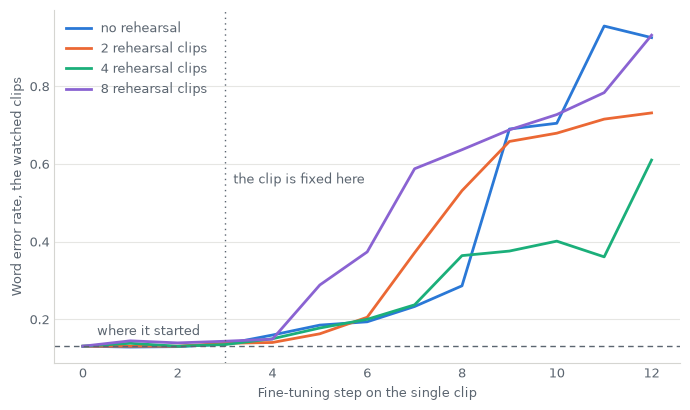

In [10]:
#| label: fig-rehearsal
#| fig-cap: The same clip, the same learning rate, the same thirteen steps. Rehearsal slows the damage and does not stop it; the flat part at the left is the only place the model is both fixed and intact.
#| fig-alt: Word error rate on held-out clips over thirteen fine-tuning steps, one line per rehearsal size. All lines start flat near 0.13 for the first few steps, then climb steeply. More rehearsal delays the climb but every line ends far above where it started.

fig, ax = figure(height=4.2)
curves = [(0, naive_watched)] + [(s, r[2]) for s, r in rehearsed.items()]
for (size, watched), colour in zip(curves, COLOURS):
    ax.plot(range(STEPS), watched, color=colour, linewidth=2,
            label=f"{size} rehearsal clips" if size else "no rehearsal")
ax.axhline(naive_watched[0], color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
ax.axvline(3, color=MUTED, linewidth=1, linestyle=(0, (1, 3)))
style_axes(ax, "Fine-tuning step on the single clip",
           "Word error rate, the watched clips")
ax.annotate("where it started", xy=(0.3, naive_watched[0]), xytext=(0, 8),
            textcoords="offset points", fontsize=9, color=MUTED)
ax.annotate("the clip is fixed here", xy=(3, 0.55), xytext=(6, 0),
            textcoords="offset points", fontsize=9, color=MUTED)
legend = ax.legend(frameon=False, fontsize=9, loc="upper left")
for text in legend.get_texts():
    text.set_color(MUTED)
fig.tight_layout()


Rehearsal helps. It does not solve it.

Four clips per step is the best of the sizes tried: 0.610 at the end against 0.925
with none, and the clip itself reaches 0.000 rather than 0.044. Two clips land in
between at 0.732. Eight is worse than doing nothing, at 0.932, and the target clip
breaks with it at 0.985. That is one seed, so treat the ordering at the top end
lightly. The clip being fixed is an eighth of each batch there.

Every curve on that chart still ends far above where it started.

The left-hand edge is the part that matters. The lowest watched error any run
reaches is 0.129. The clip is already perfect at step three without rehearsal, and
step four with it, while the watched set is still at 0.136 and 0.150. Two or three
steps wide, that is the window where the model has learned the thing you wanted and
has not yet paid for it.

The window is invisible from inside the training loop. The loss on the clip falls
smoothly through it and keeps falling afterwards, the same shape on both sides of
the cliff. The only signal comes from the sixty-four clips nobody is training on,
and only if you spend the compute to measure them.


## Conclusion

* A spectrogram turns sound into a picture, and week 3's machinery then applies
* Whisper is an encoder-decoder over that picture
* Fine-tuning on one example works, and works fast
* It also costs you accuracy everywhere else, and nothing reports that
* Rehearsal slows that cost and does not remove it
* There is a two-or-three-step window where the fix has landed and the damage has
  not, and stopping inside it is the technique
* You can only see that window from the data you are *not* training on

The full project is
[on GitHub](https://github.com/RoshBeed/ai-residency/tree/main/services/whisper-fine-tuning).
